# M5 - Dense Dropout Model

In [2]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ── Environment ───────────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Datasets ──────────────────────────────────────────────────────────────────
DATASETS = {
    "SKAB": {
        "npy_dir":    "npy_skab",
        "hf_dataset": "skab-anomaly-detection",
        "window_size": 30,
        "n_features":  8,
    },
    "NAB": {
        "npy_dir":    "npy_nab",
        "hf_dataset": "nab-anomaly-detection",
        "window_size": 50,
        "n_features":  1,
    },
}

# ── Dropout sweep ─────────────────────────────────────────────────────────────
# 0.5 is the original default. We extend down to compare with M2b findings.
DROPOUT_SWEEP = [0.05, 0.1, 0.2, 0.3, 0.5]

# ── Model HP ──────────────────────────────────────────────────────────────────
N_UNITS    = 256        # first dense layer width (n_units in original)
ACTIVATION = "sigmoid"  # hidden layer activation (original default)

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = 512
PATIENCE   = 10
T_MC       = 50         # MC Dropout forward passes

# ── Learning rates (one per dataset, tuned in earlier notebooks) ──────────────
LR = {"SKAB": 1e-3, "NAB": 1e-3}

# ── HF / W&B ──────────────────────────────────────────────────────────────────
PUSH_TO_HUB     = False
USE_WANDB       = True
WANDB_PROJECT   = "iot-ad-mcd"
MODEL_REPO_NAME = "iot-ad-models"

# ── Misc ──────────────────────────────────────────────────────────────────────
SEED          = 42
OUTPUT_DIR    = "outputs"
CKPT_DIR      = "models/checkpoints"
RESULTS_FILE  = f"{OUTPUT_DIR}/baseline_results.json"
THRESHOLD_PCT = 95

In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
)
from huggingface_hub import HfApi

# ── Credentials ───────────────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import userdata

    def _secret(key, default=""):
        try:
            return userdata.get(key)
        except Exception:
            return default

    HF_USERNAME  = _secret("HF_USERNAME")
    HF_TOKEN     = _secret("HF_TOKEN")
    WANDB_KEY    = _secret("WANDB_API_KEY")
    WANDB_ENTITY = _secret("WANDB_ENTITY")
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY)
        else:
            wandb.login()
else:
    from dotenv import load_dotenv
    load_dotenv()
    HF_USERNAME="ayyoubsoullami"
    HF_TOKEN=""
    WANDB_KEY="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"
    WANDB_ENTITY="soullamiayyoub"
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY, relogin=True)
        else:
            print("WANDB_API_KEY not set - running offline")
            os.environ["WANDB_MODE"] = "offline"

if not HF_USERNAME or not HF_TOKEN:
    raise EnvironmentError(
        "HF_USERNAME or HF_TOKEN not found. "
        "Local: add to .env  |  Colab: add to Secrets panel."
    )

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device selection with CUDA health check ───────────────────────────────────
# "no kernel image available" = PyTorch compiled without kernels for this GPU.
# Fix: pip install torch --index-url https://download.pytorch.org/whl/cu121
# Fallback: CPU (slower but correct).
def _select_device():
    if not torch.cuda.is_available():
        print("CUDA not available - using CPU.")
        return torch.device("cpu")
    try:
        _probe = torch.sigmoid(torch.randn(4, 8, device="cuda"))
        _ = _probe.sum().item()          # force synchronisation
        return torch.device("cuda")
    except RuntimeError as e:
        if "no kernel image" in str(e) or "CUDA error" in str(e):
            print("=" * 60)
            print("  CUDA kernel mismatch detected.")
            print("  Your GPU needs a newer PyTorch build.")
            print("  Fix: run this in the terminal, then restart kernel:")
            print()
            print("  pip install torch --index-url \\")
            print("      https://download.pytorch.org/whl/cu121")
            print()
            print("  Falling back to CPU for now.")
            print("=" * 60)
            return torch.device("cpu")
        raise   # re-raise any other CUDA error

device = _select_device()

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)
MODEL_REPO_ID = f"{HF_USERNAME}/{MODEL_REPO_NAME}"
api = HfApi()

print(f"Environment  : {'Google Colab' if IN_COLAB else 'Local / RunPod'}")
print(f"Device       : {device}")
if device.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory // 1024**3} GB")
print(f"N_UNITS      : {N_UNITS}")
print(f"Dropout sweep: {DROPOUT_SWEEP}")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eyyoub (eyyoub-um) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  CUDA kernel mismatch detected.
  Your GPU needs a newer PyTorch build.
  Fix: run this in the terminal, then restart kernel:

  pip install torch --index-url \
      https://download.pytorch.org/whl/cu121

  Falling back to CPU for now.
Environment  : Local / RunPod
Device       : cpu
N_UNITS      : 256
Dropout sweep: [0.05, 0.1, 0.2, 0.3, 0.5]


---
## Section 1 - Architecture
### What this model does

In [4]:
class DenseDropoutModel(nn.Module):
    """
    PyTorch port of the user-provided Keras architecture.

    Original Keras:
        Dense(n_units, sigmoid) -> Dropout(p) -> Dense(n_units//4, sigmoid) -> Dense(inputs, linear)

    Key properties:
        - Asymmetric: compression happens in two steps without a mirrored decoder
        - Single dropout layer: only after the first Dense block
        - Linear output: unbounded reconstruction (no sigmoid on output)
        - Designed for use as anomaly detector via MSE reconstruction error
    """

    def __init__(self, input_dim: int, n_units: int = 256, dropout_rate: float = 0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, n_units),
            nn.Sigmoid(),
            nn.Dropout(dropout_rate),
        )
        self.bottleneck = nn.Sequential(
            nn.Linear(n_units, n_units // 4),
            nn.Sigmoid(),
        )
        self.decoder = nn.Linear(n_units // 4, input_dim)
        # linear output = no activation applied here

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        z = self.bottleneck(z)
        return self.decoder(z)


# Quick sanity check
_test_dim = 240
_m = DenseDropoutModel(_test_dim, N_UNITS, 0.5)
_x = torch.randn(4, _test_dim)
_y = _m(_x)
assert _y.shape == _x.shape, f"Output shape mismatch: {_y.shape} vs {_x.shape}"
print(f"DenseDropoutModel OK:  input {_x.shape}  output {_y.shape}")
print()
print("Architecture (SKAB, input_dim=240):")
print(f"  Linear(240, 256) -> Sigmoid -> Dropout(p) -> Linear(256, 64) -> Sigmoid -> Linear(64, 240)")
print(f"  Parameters: {sum(p.numel() for p in _m.parameters()):,}")
del _test_dim, _m, _x, _y

DenseDropoutModel OK:  input torch.Size([4, 240])  output torch.Size([4, 240])

Architecture (SKAB, input_dim=240):
  Linear(240, 256) -> Sigmoid -> Dropout(p) -> Linear(256, 64) -> Sigmoid -> Linear(64, 240)
  Parameters: 93,744


---
## Section 2 - Data Loading

In [5]:
def _load_local(ds_name, cfg):
    npy_dir = cfg["npy_dir"]
    if not os.path.isdir(npy_dir):
        return None
    arrays = {}
    for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
        path = os.path.join(npy_dir, f"{name}.npy")
        if not os.path.exists(path):
            return None
        arrays[name] = np.load(path)
    return arrays


def _load_from_hub(ds_name, cfg):
    from datasets import load_dataset as hf_load
    repo = f"{HF_USERNAME}/{cfg['hf_dataset']}"
    print(f"  Fetching {ds_name} from HF Hub: {repo} ...")
    try:
        ds = hf_load(repo)
    except Exception as e:
        print(f"  HF load failed ({e}) - trying local npy ...")
        return _load_local(ds_name, cfg)
    n_feat = cfg["n_features"]
    def to_np(split):
        X = np.stack(
            [np.array(split[f"feature_{i}"]) for i in range(n_feat)], axis=-1
        ).astype(np.float32)
        y = np.array(split["label"], dtype=np.int8)
        return X, y
    try:
        X_train, y_train = to_np(ds["train"])
        X_val,   y_val   = to_np(ds["validation"])
        X_test,  y_test  = to_np(ds["test"])
    except Exception as e:
        print(f"  Failed to parse HF data ({e})")
        return None
    return dict(
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
    )


data = {}
for ds_name, cfg in DATASETS.items():
    print(f"\n{'='*55}\n{ds_name}")
    arr = _load_local(ds_name, cfg)
    if arr is None:
        print(f"  Local npy not found - fetching from HF Hub ...")
        arr = _load_from_hub(ds_name, cfg)
    if arr is not None:
        data[ds_name] = arr
        for k, v in arr.items():
            print(f"  {k}: {v.shape}  dtype={v.dtype}")
    else:
        print(f"  ERROR: could not load {ds_name}.")

print(f"\nDatasets loaded: {list(data.keys())}")


SKAB
  Local npy not found - fetching from HF Hub ...
  Fetching SKAB from HF Hub: ayyoubsoullami/skab-anomaly-detection ...


README.md:   0%|          | 0.00/800 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/46.1M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.54M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.6M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/229577 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/30354 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97101 [00:00<?, ? examples/s]

  X_train: (229577, 50, 1)  dtype=float32
  X_val: (30354, 50, 1)  dtype=float32
  X_test: (97101, 50, 1)  dtype=float32
  y_train: (229577,)  dtype=int8
  y_val: (30354,)  dtype=int8
  y_test: (97101,)  dtype=int8

Datasets loaded: ['SKAB', 'NAB']


---
## Section 3 - Training and Inference

In [6]:
def flatten_windows(X: np.ndarray) -> np.ndarray:
    """Flatten (N, W, F) to (N, W*F) for Dense models."""
    return X.reshape(len(X), -1)


def train_model(model, X_train_flat, X_val_flat, lr: float, run_label: str):
    """Train model. Returns (best_model, best_val_loss, val_loss_history)."""
    t_dl = DataLoader(
        TensorDataset(torch.from_numpy(X_train_flat).float()),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    v_dl = DataLoader(
        TensorDataset(torch.from_numpy(X_val_flat).float()),
        batch_size=BATCH_SIZE,
    )
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    val_losses = []

    for epoch in range(EPOCHS):
        model.train()
        for (xb,) in t_dl:
            xb = xb.to(device)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            vl = sum(
                crit(model(xb.to(device)), xb.to(device)).item() * len(xb)
                for (xb,) in v_dl
            ) / len(X_val_flat)
        val_losses.append(vl)

        if vl < best_val - 1e-7:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return model, best_val, val_losses


def recon_errors_det(model, X_flat: np.ndarray) -> np.ndarray:
    """Deterministic reconstruction errors (dropout OFF)."""
    model.eval()
    t = torch.from_numpy(X_flat).float()
    errors = []
    with torch.no_grad():
        for (xb,) in DataLoader(TensorDataset(t), batch_size=512):
            xb = xb.to(device)
            errors.append(((xb - model(xb)) ** 2).mean(dim=1).cpu().numpy())
    return np.concatenate(errors)


def recon_errors_mcd(model, X_flat: np.ndarray, T: int = T_MC):
    """MC Dropout reconstruction errors (dropout ON, T passes).
    Returns (mean_error, std_error).
    """
    model.train()   # keeps Dropout active
    t = torch.from_numpy(X_flat).float()
    dl = DataLoader(TensorDataset(t), batch_size=512)
    pass_errors = []
    with torch.no_grad():
        for _ in range(T):
            run = []
            for (xb,) in dl:
                xb = xb.to(device)
                run.append(((xb - model(xb)) ** 2).mean(dim=1).cpu().numpy())
            pass_errors.append(np.concatenate(run))
    all_e = np.stack(pass_errors)           # (T, N)
    return all_e.mean(axis=0), all_e.std(axis=0)


def compute_metrics(y_true, test_scores, val_scores, unc_scores=None):
    """Compute AUC-PR, AUROC, F1, and optionally AUROC(unc)."""
    auc_pr = float(average_precision_score(y_true, test_scores))
    auroc  = float(roc_auc_score(y_true, test_scores))
    thr    = float(np.percentile(val_scores, THRESHOLD_PCT))
    f1     = float(f1_score(y_true, (test_scores >= thr).astype(int), zero_division=0))
    result = dict(
        auc_pr=round(auc_pr, 4),
        auroc=round(auroc, 4),
        f1=round(f1, 4),
        threshold=float(thr),
    )
    if unc_scores is not None:
        mask = ~np.isnan(unc_scores)
        if mask.sum() >= 10:
            result["auroc_unc"] = round(float(roc_auc_score(y_true[mask], unc_scores[mask])), 4)
            result["mean_unc"]  = float(unc_scores[mask].mean())
        else:
            result["auroc_unc"] = float("nan")
            result["mean_unc"]  = float("nan")
    return result

---
## Section 4 - Experiments

In [7]:
sweep = {}   # sweep[ds_name][key] = {det_metrics, mcd_metrics, val_loss, ...}

for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} - data not loaded.")
        continue

    arr    = data[ds_name]
    X_flat = {
        split: flatten_windows(arr[f"X_{split}"])
        for split in ("train", "val", "test")
    }
    y_test  = arr["y_test"]
    in_dim  = X_flat["train"].shape[1]
    lr      = LR[ds_name]

    # crash recovery
    partial_file = f"{OUTPUT_DIR}/m5_sweep_{ds_name.lower()}.json"
    try:
        with open(partial_file) as f:
            sweep[ds_name] = json.load(f)
        print(f"  Resumed {ds_name}: {len(sweep[ds_name])}/{len(DROPOUT_SWEEP)} done")
    except FileNotFoundError:
        sweep[ds_name] = {}

    print(f"\n{'='*65}")
    print(f"  {ds_name}  input_dim={in_dim}  n_units={N_UNITS}  lr={lr:.0e}")
    print(f"  Architecture: {in_dim} -> {N_UNITS} -> {N_UNITS//4} -> {in_dim}")
    print(f"  Sweeping dropout_rate: {DROPOUT_SWEEP}")
    print(f"{'='*65}")

    for dp in DROPOUT_SWEEP:
        key = f"dp{dp}"
        ckpt = os.path.join(CKPT_DIR, f"m5_{ds_name.lower()}_{key}.pt")

        if key in sweep[ds_name] and os.path.exists(ckpt):
            dm = sweep[ds_name][key]["det_metrics"]
            mm = sweep[ds_name][key]["mcd_metrics"]
            print(f"  cached {key:>6}  det AUC-PR={dm['auc_pr']:.4f}"
                  f"  mcd AUC-PR={mm['auc_pr']:.4f}  AUROC(unc)={mm.get('auroc_unc', float('nan')):.4f}")
            continue

        print(f"\n  dropout_rate={dp}  [{in_dim} -> {N_UNITS} -> {N_UNITS//4} -> {in_dim}]")

        model = DenseDropoutModel(in_dim, N_UNITS, dp).to(device)
        model, best_val, val_hist = train_model(model, X_flat["train"], X_flat["val"], lr, ds_name)
        print(f"    Trained {len(val_hist)} epochs  best_val={best_val:.6f}")

        torch.save(model.state_dict(), ckpt)

        # Deterministic inference
        det_test = recon_errors_det(model, X_flat["test"])
        det_val  = recon_errors_det(model, X_flat["val"])
        det_metrics = compute_metrics(y_test, det_test, det_val)
        print(f"    DET  AUC-PR={det_metrics['auc_pr']:.4f}  "
              f"AUROC={det_metrics['auroc']:.4f}  F1={det_metrics['f1']:.4f}")

        # MC Dropout inference
        mcd_mean, mcd_std = recon_errors_mcd(model, X_flat["test"])
        mcd_val_mean, _   = recon_errors_mcd(model, X_flat["val"])
        mcd_metrics = compute_metrics(y_test, mcd_mean, mcd_val_mean, mcd_std)
        print(f"    MCD  AUC-PR={mcd_metrics['auc_pr']:.4f}  "
              f"AUROC={mcd_metrics['auroc']:.4f}  F1={mcd_metrics['f1']:.4f}  "
              f"AUROC(unc)={mcd_metrics.get('auroc_unc', float('nan')):.4f}")

        entry = {
            "dropout_rate": dp,
            "input_dim":    in_dim,
            "n_units":      N_UNITS,
            "val_loss":     best_val,
            "n_epochs":     len(val_hist),
            "val_losses":   val_hist,
            "det_metrics":  det_metrics,
            "mcd_metrics":  mcd_metrics,
        }
        sweep[ds_name][key] = entry

        if USE_WANDB:
            try:
                run = wandb.init(
                    project = WANDB_PROJECT,
                    entity  = WANDB_ENTITY or None,
                    name    = f"M5_{ds_name}_dp{dp}",
                    config  = {
                        "method":      "DenseDropout",
                        "dataset":     ds_name,
                        "dropout_rate": dp,
                        "n_units":     N_UNITS,
                        "input_dim":   in_dim,
                        "lr":          lr,
                        "T_MC":        T_MC,
                        "n_epochs":    len(val_hist),
                    },
                    reinit="finish_previous",
                )
                wandb.log({
                    "val_loss":          best_val,
                    "det/auc_pr":        det_metrics["auc_pr"],
                    "det/auroc":         det_metrics["auroc"],
                    "det/f1":            det_metrics["f1"],
                    "mcd/auc_pr":        mcd_metrics["auc_pr"],
                    "mcd/auroc":         mcd_metrics["auroc"],
                    "mcd/f1":            mcd_metrics["f1"],
                    "mcd/auroc_unc":     mcd_metrics.get("auroc_unc", float("nan")),
                    "mcd/mean_unc":      mcd_metrics.get("mean_unc", float("nan")),
                })
                wandb.finish()
            except Exception as wb_err:
                print(f"    W&B log failed: {wb_err}")

        with open(partial_file, "w") as f:
            json.dump(sweep[ds_name], f, indent=2)

print("\n\nAll runs complete.")


  SKAB  input_dim=240  n_units=256  lr=1e-03
  Architecture: 240 -> 256 -> 64 -> 240
  Sweeping dropout_rate: [0.05, 0.1, 0.2, 0.3, 0.5]

  dropout_rate=0.05  [240 -> 256 -> 64 -> 240]
    Trained 100 epochs  best_val=0.002334
    DET  AUC-PR=0.7908  AUROC=0.5940  F1=0.4035
    MCD  AUC-PR=0.7935  AUROC=0.5997  F1=0.4064  AUROC(unc)=0.5072


    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.1  [240 -> 256 -> 64 -> 240]
    Trained 100 epochs  best_val=0.002494
    DET  AUC-PR=0.7905  AUROC=0.5942  F1=0.4058
    MCD  AUC-PR=0.7929  AUROC=0.5993  F1=0.4007  AUROC(unc)=0.5759


    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.2  [240 -> 256 -> 64 -> 240]
    Trained 100 epochs  best_val=0.002921
    DET  AUC-PR=0.7653  AUROC=0.5499  F1=0.3839
    MCD  AUC-PR=0.7726  AUROC=0.5625  F1=0.3989  AUROC(unc)=0.5469


    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.3  [240 -> 256 -> 64 -> 240]
    Trained 100 epochs  best_val=0.003536
    DET  AUC-PR=0.7693  AUROC=0.5628  F1=0.3719
    MCD  AUC-PR=0.7726  AUROC=0.5651  F1=0.3834  AUROC(unc)=0.6124


    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.5  [240 -> 256 -> 64 -> 240]
    Trained 100 epochs  best_val=0.005173
    DET  AUC-PR=0.7638  AUROC=0.5547  F1=0.3594
    MCD  AUC-PR=0.7728  AUROC=0.5667  F1=0.3793  AUROC(unc)=0.6324


...

    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.1  [50 -> 256 -> 64 -> 50]
    Trained 100 epochs  best_val=0.000278
    DET  AUC-PR=0.4571  AUROC=0.5907  F1=0.3160
    MCD  AUC-PR=0.4552  AUROC=0.5909  F1=0.3132  AUROC(unc)=0.5803


    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.2  [50 -> 256 -> 64 -> 50]
    Trained 100 epochs  best_val=0.000467
    DET  AUC-PR=0.4597  AUROC=0.5895  F1=0.3187
    MCD  AUC-PR=0.4625  AUROC=0.5951  F1=0.3182  AUROC(unc)=0.5801


    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.3  [50 -> 256 -> 64 -> 50]
    Trained 100 epochs  best_val=0.000668
    DET  AUC-PR=0.4585  AUROC=0.5903  F1=0.3133
    MCD  AUC-PR=0.4638  AUROC=0.5970  F1=0.3149  AUROC(unc)=0.5770


    W&B log failed: entity soullamiayyoub not found during upsertBucket

  dropout_rate=0.5  [50 -> 256 -> 64 -> 50]
    Trained 100 epochs  best_val=0.001592
    DET  AUC-PR=0.4632  AUROC=0.5948  F1=0.3121
    MCD  AUC-PR=0.4667  AUROC=0.6005  F1=0.3149  AUROC(unc)=0.5812


    W&B log failed: entity soullamiayyoub not found during upsertBucket


All runs complete.


---
## Section 5 - Results

In [12]:
# Load M1 and B3 reference from existing baseline_results.json
try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
except FileNotFoundError:
    saved = {}
    print("baseline_results.json not found - reference values will be empty")

for ds_name in sorted(sweep.keys()):
    b3_ap = saved.get(ds_name, {}).get("B3_denseae",   {}).get("metrics", {}).get("auc_pr", float("nan"))
    m1_ap = saved.get(ds_name, {}).get("M1_dense_mcd", {}).get("metrics", {}).get("auc_pr", float("nan"))
    m1_au = saved.get(ds_name, {}).get("M1_dense_mcd", {}).get("metrics", {}).get("auroc_unc", float("nan"))

    entries = sorted(sweep[ds_name].values(), key=lambda x: x["dropout_rate"])

    print(f"\n{'='*72}")
    print(f"  {ds_name}  (input_dim={entries[0]['input_dim']}  n_units={N_UNITS})")
    print(f"  Reference: B3 Dense AE = {b3_ap:.4f}  |  M1 Dense+MCD = {m1_ap:.4f}  AUROC(unc)={m1_au:.4f}")
    print(f"{'='*72}")
    print(f"  {'dp':>5}  {'DET AUC-PR':>10}  {'DET AUROC':>9}  {'DET F1':>7}"
          f"  {'MCD AUC-PR':>10}  {'MCD AUROC':>9}  {'AUROC(unc)':>10}  {'val_loss':>10}")
    print(f"  {'─'*85}")

    for e in entries:
        dp  = e["dropout_rate"]
        dm  = e["det_metrics"]
        mm  = e["mcd_metrics"]
        print(f"  {dp:>5.2f}  {dm['auc_pr']:>10.4f}  {dm['auroc']:>9.4f}  {dm['f1']:>7.4f}"
              f"  {mm['auc_pr']:>10.4f}  {mm['auroc']:>9.4f}  "
              f"{mm.get('auroc_unc', float('nan')):>10.4f}  {e['val_loss']:>10.6f}")


  NAB  (input_dim=50  n_units=256)
  Reference: B3 Dense AE = nan  |  M1 Dense+MCD = nan  AUROC(unc)=nan
     dp  DET AUC-PR  DET AUROC   DET F1  MCD AUC-PR  MCD AUROC  AUROC(unc)    val_loss
  ─────────────────────────────────────────────────────────────────────────────────────
   0.05      0.4546     0.5873   0.3143      0.4496     0.5880      0.5803    0.000165
   0.10      0.4571     0.5907   0.3160      0.4552     0.5909      0.5803    0.000278
   0.20      0.4597     0.5895   0.3187      0.4625     0.5951      0.5801    0.000467
   0.30      0.4585     0.5903   0.3133      0.4638     0.5970      0.5770    0.000668
   0.50      0.4632     0.5948   0.3121      0.4667     0.6005      0.5812    0.001592

  SKAB  (input_dim=240  n_units=256)
  Reference: B3 Dense AE = nan  |  M1 Dense+MCD = nan  AUROC(unc)=nan
     dp  DET AUC-PR  DET AUROC   DET F1  MCD AUC-PR  MCD AUROC  AUROC(unc)    val_loss
  ─────────────────────────────────────────────────────────────────────────────────────
 

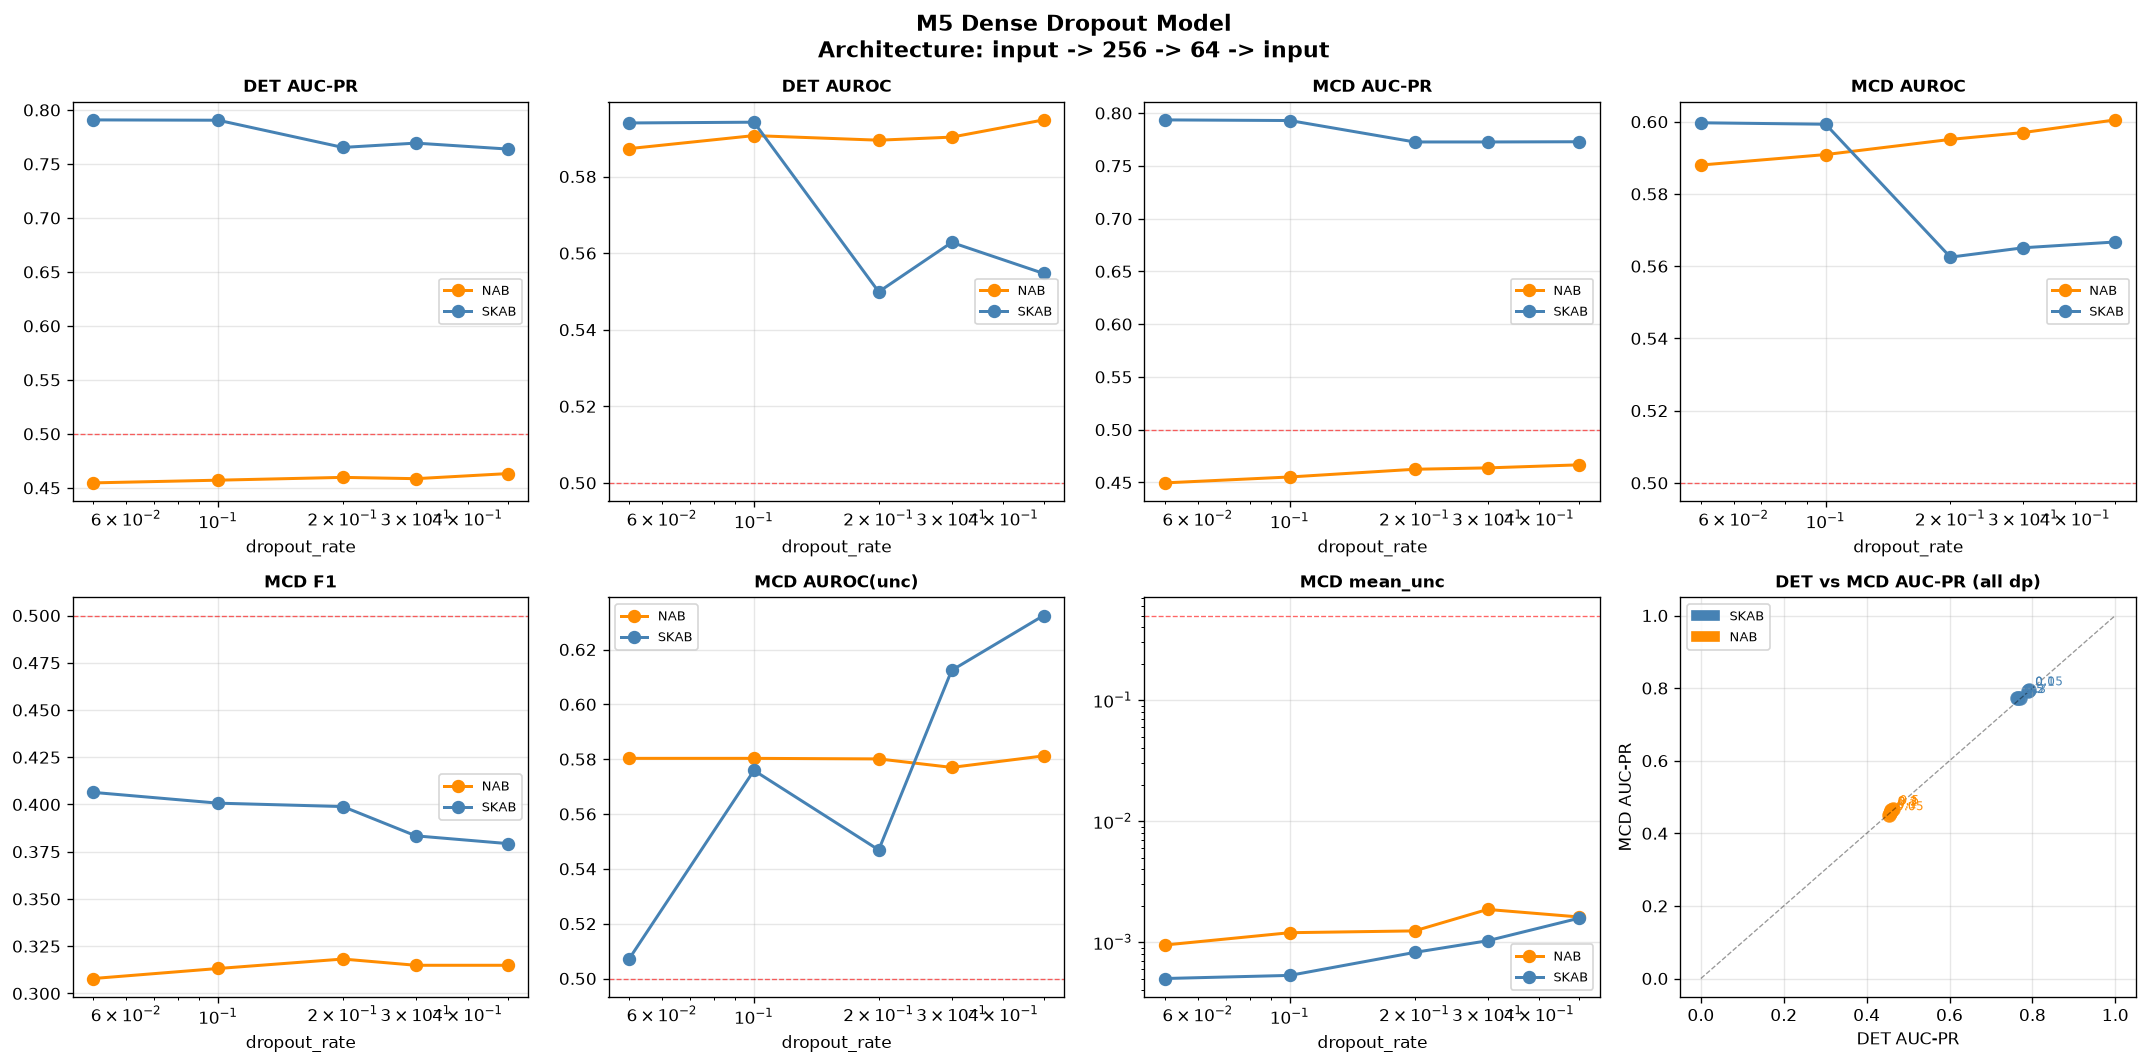

Saved outputs/m5_results.png


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f"M5 Dense Dropout Model\n"
             f"Architecture: input -> {N_UNITS} -> {N_UNITS//4} -> input",
             fontsize=13, fontweight="bold")

colors_ds  = {"SKAB": "steelblue", "NAB": "darkorange"}
PLOT_ITEMS = [
    ("det_metrics", "auc_pr",     "DET AUC-PR"),
    ("det_metrics", "auroc",      "DET AUROC"),
    ("mcd_metrics", "auc_pr",     "MCD AUC-PR"),
    ("mcd_metrics", "auroc",      "MCD AUROC"),
    ("mcd_metrics", "f1",         "MCD F1"),
    ("mcd_metrics", "auroc_unc",  "MCD AUROC(unc)"),
    ("mcd_metrics", "mean_unc",   "MCD mean_unc"),
    (None,          None,          "DET vs MCD AUC-PR (all dp)"),
]

for ax_i, (section, metric, title) in enumerate(PLOT_ITEMS):
    ax = axes[ax_i // 4][ax_i % 4]
    ax.set_title(title, fontsize=10, fontweight="bold")

    if section is not None:
        for ds_name in sorted(sweep.keys()):
            entries = sorted(sweep[ds_name].values(), key=lambda x: x["dropout_rate"])
            dps  = [e["dropout_rate"] for e in entries]
            vals = [e[section].get(metric, float("nan")) for e in entries]
            ax.plot(dps, vals, "o-", lw=1.8, ms=7,
                    color=colors_ds[ds_name], label=ds_name)
        ax.set_xlabel("dropout_rate")
        ax.set_xscale("log")
        if metric == "mean_unc":
            ax.set_yscale("log")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.axhline(0.5, color="red", ls="--", lw=0.8, alpha=0.6, label="0.5 ref")

    else:
        # Scatter: DET AUC-PR vs MCD AUC-PR per point
        for ds_name in sorted(sweep.keys()):
            entries = sorted(sweep[ds_name].values(), key=lambda x: x["dropout_rate"])
            for e in entries:
                x_val = e["det_metrics"]["auc_pr"]
                y_val = e["mcd_metrics"]["auc_pr"]
                dp    = e["dropout_rate"]
                ax.scatter(x_val, y_val, s=60, color=colors_ds[ds_name], alpha=0.85)
                ax.annotate(f"{dp}", (x_val, y_val), textcoords="offset points",
                            xytext=(4, 3), fontsize=7, color=colors_ds[ds_name])
        ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4, label="DET = MCD")
        ax.set_xlabel("DET AUC-PR")
        ax.set_ylabel("MCD AUC-PR")
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(color=c, label=d) for d, c in colors_ds.items()],
            fontsize=8,
        )
        ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = f"{OUTPUT_DIR}/m5_results.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

---
## Section 6 - Save Best Result

In [14]:
# Find best dropout per dataset (by MCD AUC-PR - our primary metric)
best_per_ds = {}
for ds_name in sorted(sweep.keys()):
    entries = sorted(
        sweep[ds_name].values(),
        key=lambda x: x["mcd_metrics"]["auc_pr"],
        reverse=True,
    )
    best = entries[0]
    best_per_ds[ds_name] = best
    print(f"{ds_name}  best dp={best['dropout_rate']}  "
          f"DET AUC-PR={best['det_metrics']['auc_pr']:.4f}  "
          f"MCD AUC-PR={best['mcd_metrics']['auc_pr']:.4f}  "
          f"AUROC(unc)={best['mcd_metrics'].get('auroc_unc', float('nan')):.4f}")

# Merge into baseline_results.json
try:
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
except FileNotFoundError:
    all_results = {}

for ds_name, best in best_per_ds.items():
    if ds_name not in all_results:
        all_results[ds_name] = {}
    all_results[ds_name]["M5_dense_dropout"] = {
        "dropout_rate": best["dropout_rate"],
        "n_units":      best["n_units"],
        "input_dim":    best["input_dim"],
        "val_loss":     best["val_loss"],
        "metrics":      best["mcd_metrics"],   # MCD metrics as primary
        "det_metrics":  best["det_metrics"],
    }

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\nSaved M5_dense_dropout to {RESULTS_FILE}")
print("Keys:", {ds: list(all_results[ds].keys()) for ds in all_results})

NAB  best dp=0.5  DET AUC-PR=0.4632  MCD AUC-PR=0.4667  AUROC(unc)=0.5812
SKAB  best dp=0.05  DET AUC-PR=0.7908  MCD AUC-PR=0.7935  AUROC(unc)=0.5072

Saved M5_dense_dropout to outputs/baseline_results.json
Keys: {'NAB': ['M5_dense_dropout'], 'SKAB': ['M5_dense_dropout']}


In [18]:
print("=" * 72)
print("  M5 Dense Dropout Model - FINAL SUMMARY")
print("=" * 72)

try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
except FileNotFoundError:
    saved = {}

for ds_name in sorted(sweep.keys()):
    b3  = saved.get(ds_name, {}).get("B3_denseae",   {}).get("metrics", {})
    m1  = saved.get(ds_name, {}).get("M1_dense_mcd", {}).get("metrics", {})
    m5  = saved.get(ds_name, {}).get("M5_dense_dropout", {})

    print(f"\n  {ds_name}")
    print(f"  {'─'*55}")
    print(f"  {'Method':25s}  {'AUC-PR':>8}  {'AUROC':>7}  {'F1':>7}  {'AUROC(unc)':>10}")
    print(f"  {'─'*55}")

    def row(name, m, unc_key="auroc_unc"):
        ap = m.get("auc_pr",   float("nan"))
        ar = m.get("auroc",    float("nan"))
        f1 = m.get("f1",       float("nan"))
        au = m.get(unc_key,    float("nan"))
        print(f"  {name:25s}  {ap:>8.4f}  {ar:>7.4f}  {f1:>7.4f}  {au:>10.4f}")

    row("B3 Dense AE (reference)", b3)
    row("M1 Dense + MCD",          m1)
    if m5:
        row(f"M5 Dense Dropout (det)",  m5.get("det_metrics", {}))
        row(f"M5 Dense Dropout (mcd)",  m5.get("metrics", {}))

print()
print(f"  Plots   -> {OUTPUT_DIR}/m5_results.png")
print(f"  Results -> {RESULTS_FILE}")
print("=" * 72)

  M5 Dense Dropout Model - FINAL SUMMARY

  NAB
  ───────────────────────────────────────────────────────
  Method                       AUC-PR    AUROC       F1  AUROC(unc)
  ───────────────────────────────────────────────────────
  B3 Dense AE (reference)      0.4672   0.6012   0.3183         nan
  M1 Dense + MCD               0.4631   0.5934   0.3182      0.5835

  SKAB
  ───────────────────────────────────────────────────────
  Method                       AUC-PR    AUROC       F1  AUROC(unc)
  ───────────────────────────────────────────────────────
  B3 Dense AE (reference)      0.7960   0.6105   0.3914         nan
  M1 Dense + MCD               0.7657   0.5470   0.4186      0.4015

  Plots   -> outputs/m5_results.png
  Results -> outputs/baseline_results.json
